## Classificatore Baseline — EfficientNetB3 con Fine-Tuning

Classificatore binario (cancro / non cancro) su mammografie con **EfficientNetB3** (ImageNet) e training in due fasi:

1. **Head Training** — backbone congelato, solo la custom head (GAP → Dense(256) → BN → LeakyReLU → Dropout(0.5) → sigmoid). Loss: `BinaryCrossentropy`, class weights bilanciati, Adam lr=1e-3.
2. **Fine-Tuning** — sblocco parziale del backbone da `block6a_expand_conv` (BN restano congelati). Loss: `BinaryFocalCrossentropy` (γ=2, α=0.75), Adam lr=1e-5 con ReduceLROnPlateau.

Valutazione con soglia ottimale (indice di Youden), metriche su validation set e Grad-CAM per l'interpretabilità.


In [16]:
import os
import sys

# Controlla se il notebook sta girando su Google Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: ", BASE_PATH)

Ambiente locale rilevato.
Percorso base:  ../


#### Import Librerie

In [17]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from sklearn.utils.class_weight import compute_class_weight
from datetime import date

#### Configurazione

In [18]:
# Cartella esperimento
OUTPUT_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(OUTPUT_DIR)

../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16


In [19]:
# Definizione percorsi
TRAIN_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "train.csv")
VAL_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', "val.csv")

IMG_SIZE = (300, 300) # Dimensione standard EfficientNetB3
BATCH_SIZE = 16 
SEED = 42 

# Medie e std di ImageNet
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD = tf.constant([0.229, 0.224, 0.225])

# Imposta il seed per la riproducibilità
keras.utils.set_random_seed(SEED)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

../data/processed/metadata/train.csv
../data/processed/metadata/val.csv


#### Verifica presenza file dataset preprocessato

Verifica se il dataset preprocessato è già presente in locale (CSV + immagini). Se non lo trova, scarica il file `.zip` da Google Drive tramite `gdown`, lo estrae nella cartella `data/processed/` e rimuove l'archivio.


In [20]:
# ID del file su Google Drive
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def processed_data_ready():
    if not os.path.isfile(TRAIN_CSV_PATH) or not os.path.isfile(VAL_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TRAIN_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not processed_data_ready():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print(f"Dataset estratto in: {os.path.join(BASE_PATH, 'data')}")
else:
    print("Dataset già presente, salto il download")


Dataset già presente, salto il download


#### Preparazione Dataset e Pipeline di Input

Carica i CSV di train e validation, calcola i **pesi delle classi** (bilanciamento del dataset sbilanciato tra casi positivi e negativi) e costruisce la pipeline `tf.data`.

**Preprocessing applicato ad ogni immagine:**
- Decodifica in scala di grigi (1 canale) e resize a `IMG_SIZE`
- Normalizzazione in `[0, 1]` e replica su 3 canali
- Standardizzazione con media e deviazione standard ImageNet

**Data Augmentation** (opzionale, al momento disabilitata): flip orizzontale e variazione casuale di luminosità. Escluse rotazioni verticali e zoom per non introdurre artefatti irrealistici nelle mammografie.


In [21]:
# Carica e filtra i CSV di train e validation
df_train = pd.read_csv(TRAIN_CSV_PATH).reset_index(drop=True)
df_val = pd.read_csv(VAL_CSV_PATH).reset_index(drop=True)

def fix_path(p):
    if os.path.isabs(p) or p.startswith('../') or p.startswith('./'):
        return p
    return os.path.join(BASE_PATH, p)

df_train['processed_path'] = df_train['processed_path'].apply(fix_path)
df_val['processed_path'] = df_val['processed_path'].apply(fix_path)

# Calcola i pesi delle classi per il training
labels_train = df_train['cancer'].values
classes = np.unique(labels_train)
weights = compute_class_weight('balanced', classes=classes, y=labels_train)
class_weight_dict = dict(zip(classes.astype(int), weights))
print(f"Class Weights: {class_weight_dict}")

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=1, expand_animations=False) # RGB -> GrayScale
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1) # Immagini a 3 canali colore
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
        
    return img, tf.cast(label, tf.float32)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    img = tf.clip_by_value(img, -3.0, 3.0)
    return img, label
# Niente rotazioni forti (come rotazione verticale), nemmeno zoom

def make_dataset(df, shuffle=False, augment_data=False):
    paths = df['processed_path'].values
    labels = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    ds = ds.map(lambda p, l: load_and_preprocess(p, l), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Costruisci i dataset
train_ds = make_dataset(df_train, shuffle=True, augment_data=False) # Da mettere a True se vuoi data augmentation
val_ds = make_dataset(df_val, shuffle=False, augment_data=False) 

Class Weights: {0: 0.5999412110523221, 1: 3.001470588235294}


#### Configurazione e Salvataggio dell'Esperimento

In [22]:
experiment_config = {
    "experiment_name": os.path.basename(OUTPUT_DIR),
    "date": date.today().isoformat(),
    "backbone": {
        "name": "EfficientNetB3",
        "weights": "imagenet",
        "input_shape": list(IMG_SIZE) + [3],
        "include_top": False,
    },
    "head": {
        "pooling": "GlobalAveragePooling2D",
        "dense_units": 256,
        "l2_regularization": 1e-4,
        "activation": "LeakyReLU(negative_slope=0.1)",
        "dropout": 0.5,
        "output": "Dense(1, sigmoid)",
    },
    "preprocessing": {
        "img_size": list(IMG_SIZE),
        "normalization": "ImageNet mean/std",
        "imagenet_mean": [0.485, 0.456, 0.406],
        "imagenet_std": [0.229, 0.224, 0.225],
    },
    "data": {
        "batch_size": BATCH_SIZE,
        "seed": SEED,
        "augmentation": False,
        "train_csv": TRAIN_CSV_PATH,
        "val_csv": VAL_CSV_PATH,
    },
    "phase1_head_training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "binary_crossentropy",
        "max_epochs": 25,
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 7,
        "class_weight": "balanced",
        "backbone_trainable": False,
    },
    "phase2_fine_tuning": {
        "optimizer": "Adam",
        "learning_rate": 1e-5,
        "loss": "BinaryFocalCrossentropy",
        "BinaryFocalCrossentropy_gamma": 2.0,
        "BinaryFocalCrossentropy_alpha": 0.75,
        "max_epochs": 30,
        "fine_tune_from_layer": "block6a_expand_conv",
        "early_stopping_monitor": "val_auc",
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 1e-3,
        "reduce_lr_factor": 0.5,
        "reduce_lr_patience": 3,
        "min_lr": 1e-7,
        "class_weight": "none",
    },
}

config_path = os.path.join(OUTPUT_DIR, 'experiment_config.json')
with open(config_path, 'w') as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)
print(f"Configurazione esperimento salvata in: {config_path}")


Configurazione esperimento salvata in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/experiment_config.json


#### Costruzione del Modello — Fase 1 (Head Training)

Il modello segue un'architettura **feature extractor + custom head**:

- **Backbone**: EfficientNetB3 pre-addestrato su ImageNet, **congelato** (`trainable=False`)
- **Head**: GlobalAveragePooling → Dense(256) con L2 + BatchNorm + LeakyReLU + Dropout(0.5) → uscita sigmoidea per classificazione binaria

`training=False` nel forward pass del backbone mantiene le sue BatchNorm in modalità inferenza anche durante il training, evitando di corrompere le statistiche apprese.

La funzione restituisce sia `model` che `base_model` per permettere lo sblocco selettivo dei layer nella fase di fine-tuning.


In [23]:
def build_base_model():
    # Carica il backbone EfficientNetB3 pre-addestrato
    base_model = keras.applications.EfficientNetB3(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE + (3,)
    )
    
    # Congela il backbone per l'addestramento della Custom Head
    base_model.trainable = False
    
    # Costruzione dell'architettura completa
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    
    x = base_model(inputs, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.Dropout(0.5)(x)
    
    # Sigmoide per classificazione binaria
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs, name="baseline_efficientnetb3")
    return model, base_model

model, base_model = build_base_model()
model.summary()


Model: "baseline_efficientnetb3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,288 (42.64 MB)

 Trainable params: 394,241 (1.50 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

## Compilazione e Training — Fase 1 (Head Training)

Il backbone rimane congelato: si addestrano solo i layer della custom head.

- **Loss**: `binary_crossentropy` — classificazione binaria (cancro / non cancro)
- **Metrica principale**: AUC — più robusta dell'accuracy su dataset sbilanciati
- **Class weight**: penalizza gli errori sulla classe minoritaria (casi positivi)
- **Early stopping**: patience 7 epoche su `val_auc`


In [24]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase1 = [
    # Monitor su val_auc: metrica più robusta dell'accuracy per dataset sbilanciati
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_fase1_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_DIR, 'training_log_fase1.csv'),
        separator=',',
        append=False
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    class_weight=class_weight_dict, # Compensa lo sbilanciamento del train set
    callbacks=callbacks_fase1
)

Epoch 1/25


I0000 00:00:1781799134.506544   33575 service.cc:153] XLA service 0x739be00a25c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781799134.506687   33575 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781799136.363401   33575 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781799140.859792   33575 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781799142.034342   33575 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_54322__.413
E0000 00:00:1781799146.744748   33575 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799147.557872   33575 cuda_timer.cc:87] Delay kernel time

127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.5063 - auc: 0.4995 - loss: 0.9539 - precision: 0.1565 - recall: 0.4728

I0000 00:00:1781799199.749647   33573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_54322__.413
E0000 00:00:1781799202.558715   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799204.081117   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799206.359684   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799207.628267   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799210.790650   33573 cuda_timer.cc:87] Delay kernel timed ou

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.5065 - auc: 0.4997 - loss: 0.9537 - precision: 0.1567 - recall: 0.4731

...

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.6276 - auc: 0.6933 - loss: 0.6800 - precision: 0.2575 - recall: 0.6559 - val_accuracy: 0.4485 - val_auc: 0.6302 - val_loss: 0.8087 - val_precision: 0.2021 - val_recall: 0.7808
Epoch 9/25
  2/128 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.6719 - auc: 0.7986 - loss: 0.5503 - precision: 0.2500 - recall: 1.0000  

W0000 00:00:1781799352.417099   46240 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.5987 - auc: 0.6575 - loss: 0.7045 - precision: 0.2336 - recall: 0.6176 - val_accuracy: 0.4760 - val_auc: 0.6369 - val_loss: 0.8034 - val_precision: 0.2111 - val_recall: 0.7808
Epoch 10/25
  2/128 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8438 - auc: 0.8984 - loss: 0.8512 - precision: 0.7837 - recall: 0.8466  

W0000 00:00:1781799362.016436   46240 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.5997 - auc: 0.6587 - loss: 0.7021 - precision: 0.2405 - recall: 0.6500 - val_accuracy: 0.4943 - val_auc: 0.6138 - val_loss: 0.7819 - val_precision: 0.2109 - val_recall: 0.7397


#### Fine-Tuning — Fase 2 (Sblocco Parziale del Backbone)

Il backbone viene parzialmente sbloccato a partire da `block6a_expand_conv` (ultimi blocchi di EffNetB3),
mentre i layer precedenti e tutti i BatchNorm restano congelati per preservare le statistiche ImageNet.

- **Loss**: `BinaryFocalCrossentropy` — penalizza gli esempi difficili (`gamma=2`) e bilancia le classi (`alpha=0.75` al cancro)
- **class_weight rimosso**: il bilanciamento è già gestito da `apply_class_balancing=True`; applicarli insieme duplicherebbe la correzione
- **LR = 1e-5**: ordine di grandezza inferiore alla fase 1 per aggiornamenti graduali sui pesi pre-addestrati
- **ReduceLROnPlateau**: dimezza il LR se `val_auc` non migliora per 3 epoche, fino a un minimo di `1e-7`


In [25]:
base_model.trainable = True
set_trainable = False

for layer in base_model.layers:
    if layer.name == 'block6a_expand_conv':
        set_trainable = True
    layer.trainable = set_trainable

# Freeze dei BatchNorm: anche nei layer sbloccati,
# le statistiche BN restano quelle di ImageNet
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Totale layer nel base_model: {len(base_model.layers)}")
n_trainable_layers = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer trainable nel base_model: {n_trainable_layers}/{len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), # Learning Rate basso per non distruggere i pesi ImageNet nei layer sbloccati
    loss=keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
        alpha=0.75, # Peso alla classe positiva (cancer): 0.75 vs 0.25 per i negativi
        gamma=2.0, # Riduce il peso degli esempi già ben classificati
        from_logits=False
    ),
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.Precision(name='precision')
    ]
)

callbacks_fase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        min_delta=1e-3,
        restore_best_weights=True,
        mode='max'
    ),
    keras.callbacks.ModelCheckpoint(
        os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras'),
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=3,
        mode='max',
        min_lr=1e-7
    ),
    keras.callbacks.CSVLogger(
        os.path.join(OUTPUT_DIR, 'training_log_fase2.csv'),
        separator=',',
        append=False
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    #class_weight=class_weight_dict,
    callbacks=callbacks_fase2
)

print(f"\nTraining completato. Il miglior modello è salvato in: {os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')}")


Totale layer nel base_model: 385
Layer trainable nel base_model: 95/385
Epoch 1/30


I0000 00:00:1781799410.195336   33570 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_110303__.413
E0000 00:00:1781799413.640944   33570 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799414.690507   33570 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5523 - auc: 0.6141 - loss: 0.1340 - precision: 0.2161 - recall: 0.6427

I0000 00:00:1781799461.733587   33573 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_110303__.413
E0000 00:00:1781799464.333859   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799469.633774   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


128/128 ━━━━━━━━━━━━━━━━━━━━ 147s 583ms/step - accuracy: 0.5473 - auc: 0.6133 - loss: 0.1308 - precision: 0.2137 - recall: 0.6412 - val_accuracy: 0.3135 - val_auc: 0.6602 - val_loss: 0.1368 - val_precision: 0.1924 - val_recall: 0.9726 - learning_rate: 1.0000e-05
Epoch 2/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.5826 - auc: 0.6481 - loss: 0.1211 - precision: 0.2305 - recall: 0.6441 - val_accuracy: 0.5606 - val_auc: 0.6437 - val_loss: 0.1038 - val_precision: 0.2069 - val_recall: 0.5753 - learning_rate: 1.0000e-05
Epoch 3/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.5870 - auc: 0.6244 - loss: 0.1211 - precision: 0.2177 - recall: 0.5706 - val_accuracy: 0.6156 - val_auc: 0.6392 - val_loss: 0.1022 - val_precision: 0.2189 - val_recall: 0.5068 - learning_rate: 1.0000e-05
Epoch 4/30
128/128 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.6134 - auc: 0.6480 - loss: 0.1169 - precision: 0.2393 - recall: 0.6059 - val_accuracy: 0.7002 - val_auc: 0.6229 - val_loss: 0

#### Visualizzazione Curve di Training

Plot Loss e AUC (train vs validation) per entrambe le fasi, salvati in `figures/`.

Analisi Overfitting - Fase 1 (Feature Extraction):
Grafico salvato in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/training_history_fase1.png


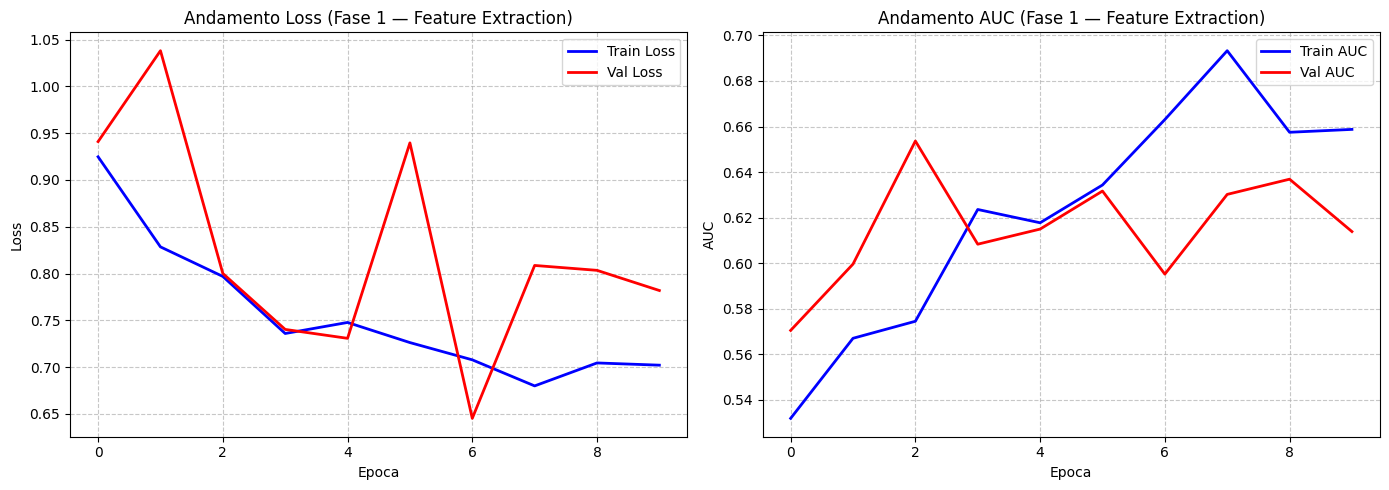

Analisi Overfitting - Fase 2 (Fine Tuning):
Grafico salvato in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/training_history_fase2.png


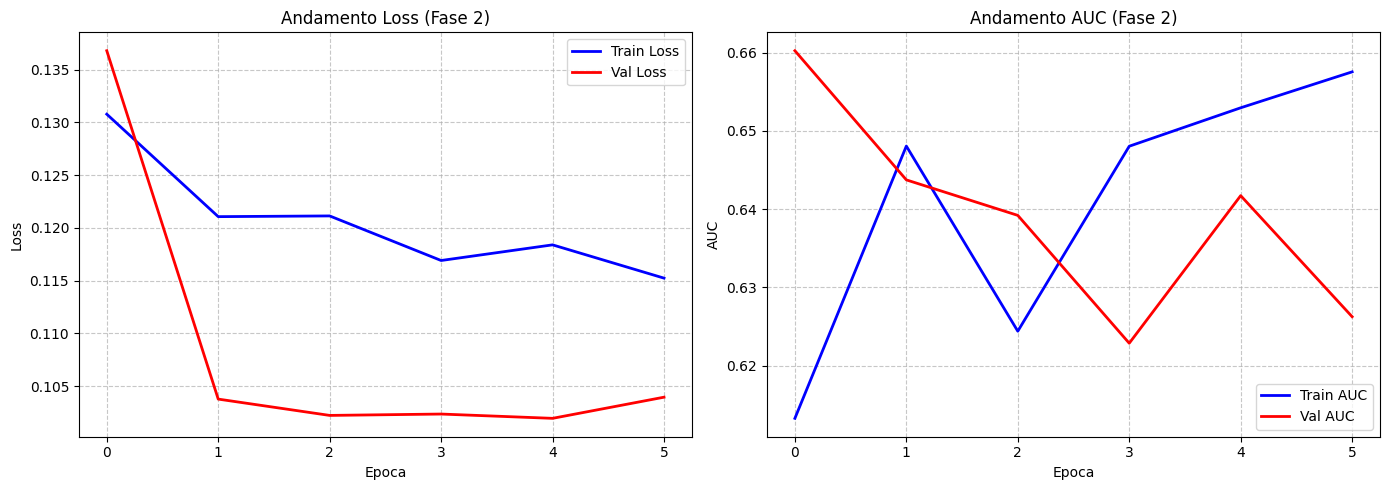

In [26]:
def plot_training_history(history, title_suffix="", save_path=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', color='red', linewidth=2)
    ax1.set_title(f'Andamento Loss {title_suffix}')
    ax1.set_xlabel('Epoca')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)

    ax2.plot(history.history['auc'], label='Train AUC', color='blue', linewidth=2)
    ax2.plot(history.history['val_auc'], label='Val AUC', color='red', linewidth=2)
    ax2.set_title(f'Andamento AUC {title_suffix}')
    ax2.set_xlabel('Epoca')
    ax2.set_ylabel('AUC')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Grafico salvato in: {save_path}")
    plt.show()

FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Analisi Overfitting - Fase 1 (Feature Extraction):")
plot_training_history(
    history_phase1, "(Fase 1 — Feature Extraction)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase1.png')
)

print("Analisi Overfitting - Fase 2 (Fine Tuning):")
plot_training_history(
    history_phase2, "(Fase 2)",
    save_path=os.path.join(FIGURES_DIR, 'training_history_fase2.png')
)

#### Valutazione sul Validation Set

Carica il miglior modello salvato e calcola le predizioni sull'intero validation set

- **Soglia ottimale**: determinata con l'indice di Youden (massimizza sensibilità + specificità), più adatta della soglia fissa 0.5 su dataset sbilanciati. Bilancia meglio i falsi negativi (tumori mancati) e falsi positivi
- **Metriche**: AUC, precision, recall e F1 calcolate sulla classe positiva (cancro) e salvate in `val_metrics.json`
- **Figure**: Confusion Matrix e ROC Curve salvate in `figures/`


AUC: 0.6605
Soglia ottimale: 0.615
              precision    recall  f1-score   support

   No cancro       0.91      0.55      0.68       364
      Cancro       0.24      0.73      0.36        73

    accuracy                           0.58       437
   macro avg       0.58      0.64      0.52       437
weighted avg       0.80      0.58      0.63       437

Metriche salvate in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/val_metrics.json


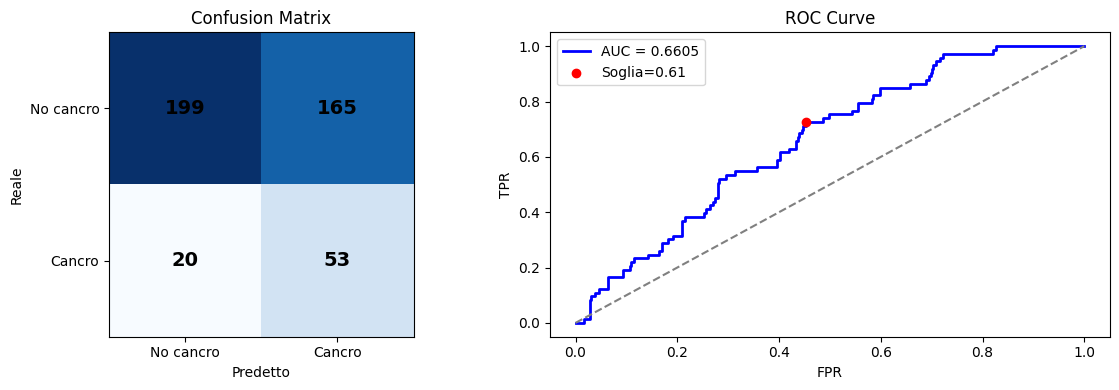

Figura salvata in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/val_confusion_roc.png


In [27]:
from sklearn.metrics import (confusion_matrix, roc_curve,
                             classification_report, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Carica il miglior modello salvato
best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')
)

# Predizioni sul validation set
y_true, y_pred_prob = [], []
for imgs, labels in val_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Soglia ottimale (Youden's J)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
youden_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[youden_idx]
y_pred = (y_pred_prob >= best_threshold).astype(int)

val_auc = roc_auc_score(y_true, y_pred_prob)
report_str = classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro'])

print(f"AUC: {val_auc:.4f}")
print(f"Soglia ottimale: {best_threshold:.3f}")
print(report_str)

# Salva metriche in JSON
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

metrics_dict = {
    'split': 'validation',
    'backbone': 'EfficientNetB3',
    'experiment_name': os.path.basename(OUTPUT_DIR),
    'auc': round(float(val_auc), 4),
    'optimal_threshold_youden': round(float(best_threshold), 4),
    'accuracy': round(float((y_pred == y_true).mean()), 4),
    'precision_cancer': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'recall_cancer':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'f1_cancer':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
    'classification_report': report_str,
}
metrics_path = os.path.join(OUTPUT_DIR, 'val_metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print(f"Metriche salvate in: {metrics_path}")

# Figura: Confusion Matrix + ROC curve
cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No cancro', 'Cancro'])
axes[0].set_yticklabels(['No cancro', 'Cancro'])
axes[0].set_xlabel('Predetto'); axes[0].set_ylabel('Reale')
axes[0].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14, fontweight='bold')

axes[1].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {val_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].scatter(fpr[youden_idx], tpr[youden_idx], color='red', zorder=5, label=f'Soglia={best_threshold:.2f}')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'val_confusion_roc.png')
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura salvata in: {fig_path}")

#### Grad-CAM — Interpretabilità del Modello

Visualizza le regioni dell'immagine che hanno maggiormente influenzato la predizione, calcolando i gradienti dell'output rispetto alle feature map finali del backbone.

Per ogni campione vengono mostrati: immagine originale con heatmap sovrapposta e heatmap isolata.
Utile per verificare che il modello si concentri su aree anatomicamente rilevanti anziché su artefatti.


Modello caricato: baseline_efficientnetb3


E0000 00:00:1781799634.926688   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799635.753936   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799637.306780   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1781799641.301621   33573 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


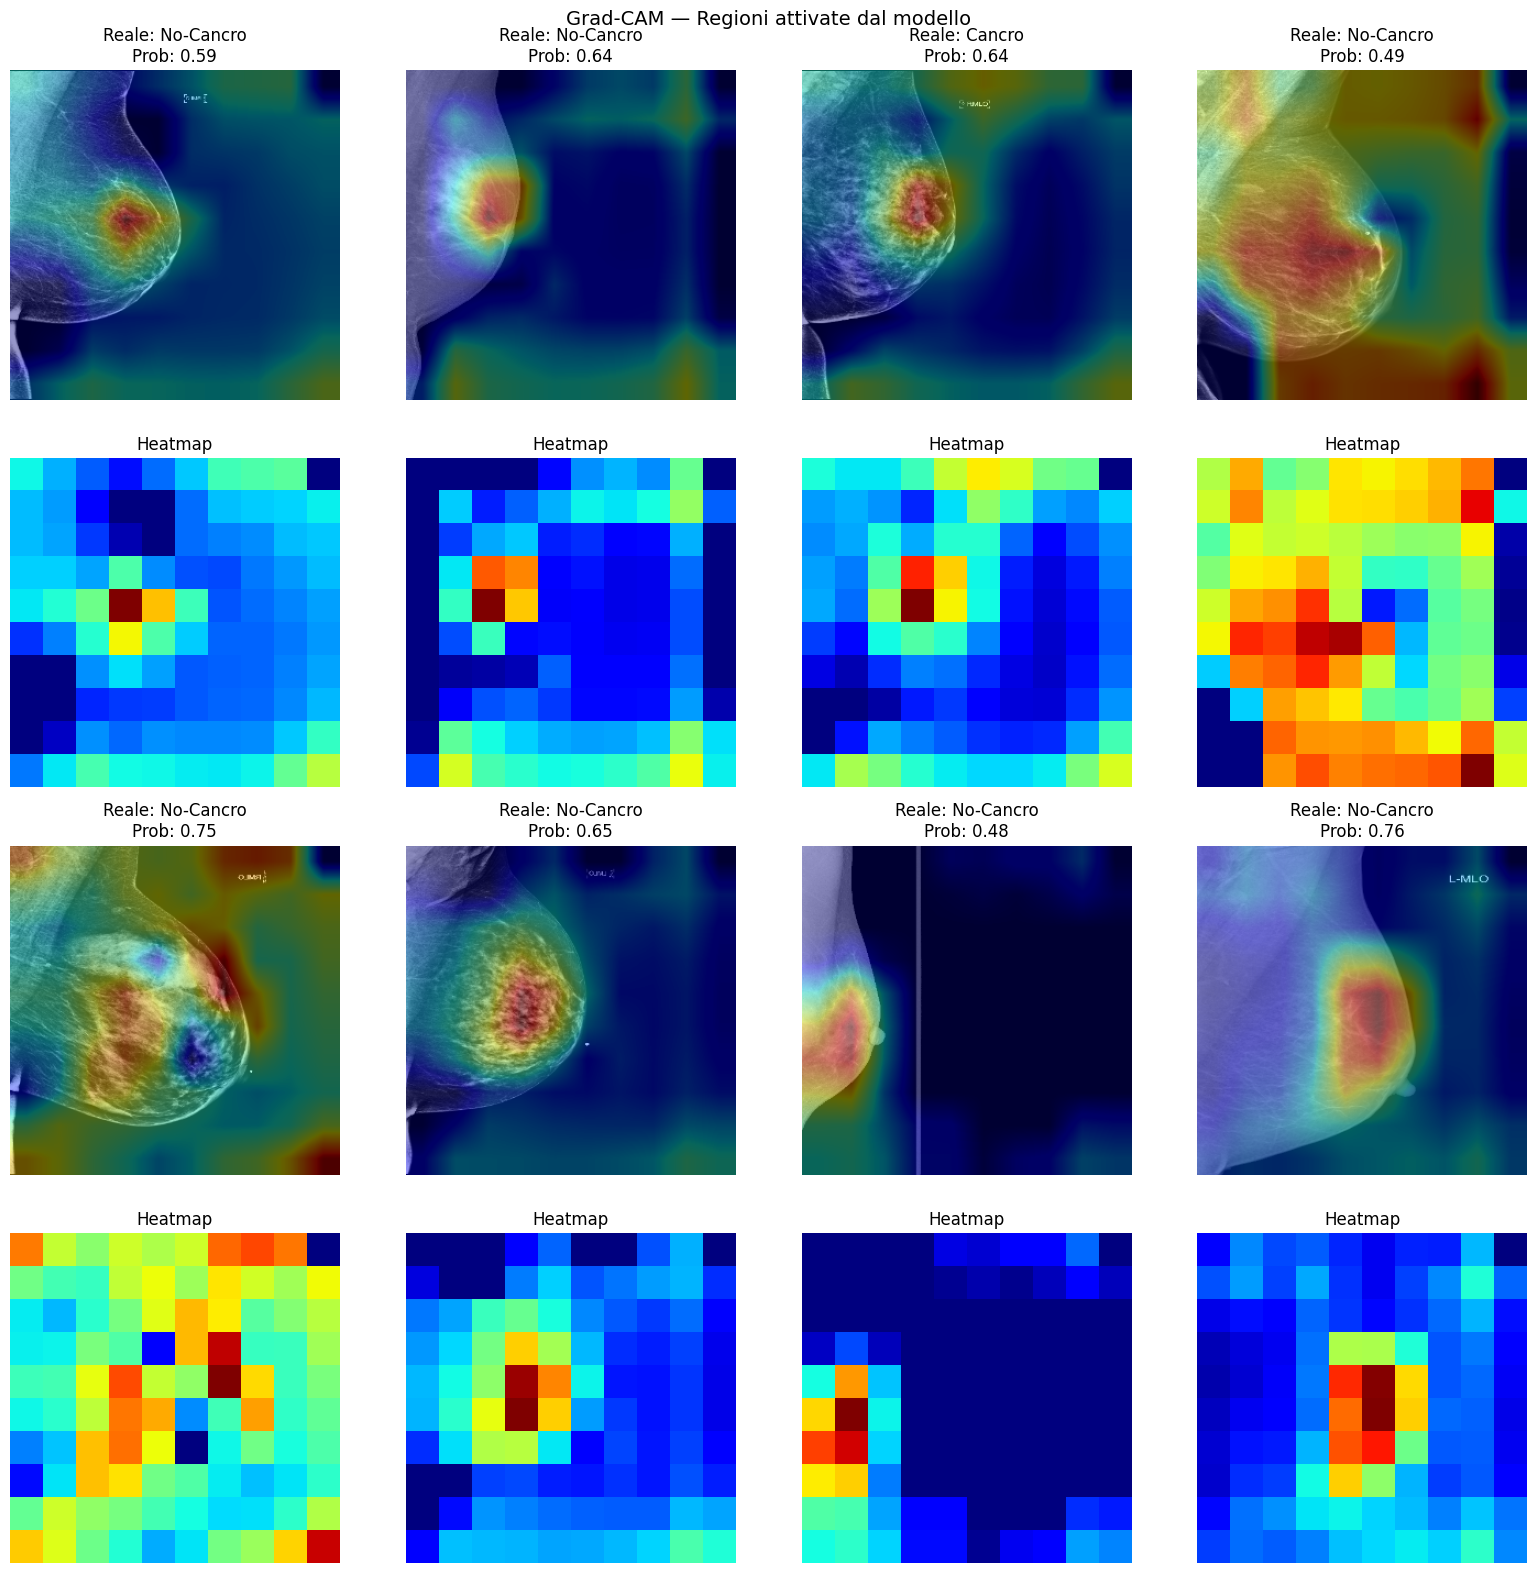

Grad-CAM salvato in: ../experiments/exp20260618_baseline_efficientnetb3_fine_tuned_batch_size_16/figures/gradcam_examples.png


In [28]:
# Carica il modello già addestrato 
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')

best_model = keras.models.load_model(
    os.path.join(OUTPUT_DIR, 'baseline_efficientnetb3_final_best.keras')
)
print(f"Modello caricato: {best_model.name}")


def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('efficientnetb3')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]

    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)  
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x

    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis] # Combinazione pesata delle feature map: canali più rilevanti contribuiscono di più
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()



def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img_vis = np.clip(img_vis, 0, 1)
    img_vis_gray = img_vis[:, :, 0]  # canale singolo (mammografia)

    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis_gray, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title)
    ax.axis('off')


# Mostra Grad-CAM su 8 esempi del validation set
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
sample_count = 0
for imgs, labels in val_ds:
    for i in range(len(imgs)):
        if sample_count >= 8:
            break
        img = imgs[i:i+1]
        label = int(labels[i].numpy())
        prob = float(best_model.predict(img, verbose=0)[0][0])
        heatmap = make_gradcam_heatmap(img, best_model)

        row_img = (sample_count // 4) * 2       
        row_heat = row_img + 1                 
        col = sample_count % 4                  

        show_gradcam(imgs[i], heatmap, axes[row_img, col],
                     title=f"Reale: {'Cancro' if label==1 else 'No-Cancro'}\nProb: {prob:.2f}")
        axes[row_heat, col].imshow(heatmap, cmap='jet')
        axes[row_heat, col].set_title("Heatmap")
        axes[row_heat, col].axis('off')
        sample_count += 1
    if sample_count >= 8:
        break

plt.suptitle("Grad-CAM — Regioni attivate dal modello", fontsize=14)
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'gradcam_examples.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Grad-CAM salvato in: {gradcam_path}")
